<a href="https://colab.research.google.com/github/RohitKhobare/ML-Lab-Assignments/blob/main/ML_LA6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 77.5k/77.5k [00:00<00:00, 45.9MB/s]

Extracting files...
Dataset loaded successfully! Initial shape: (2823, 25)


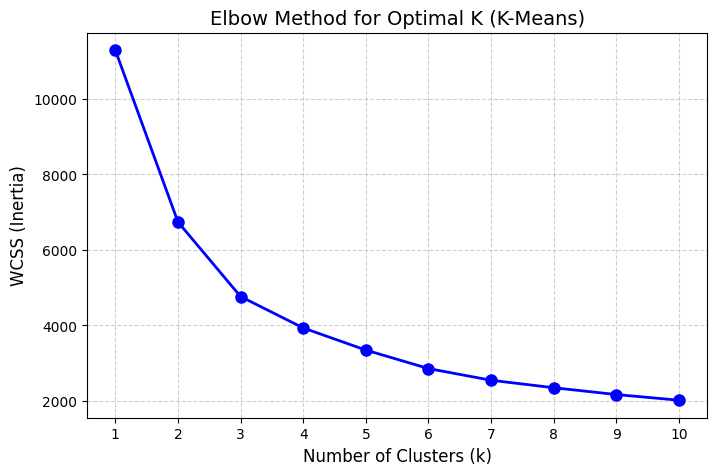


Optimal Clusters determined by Elbow Method: 3

K-Means Cluster Counts:
KMeans_Cluster
0    975
1    852
2    996
Name: count, dtype: int64


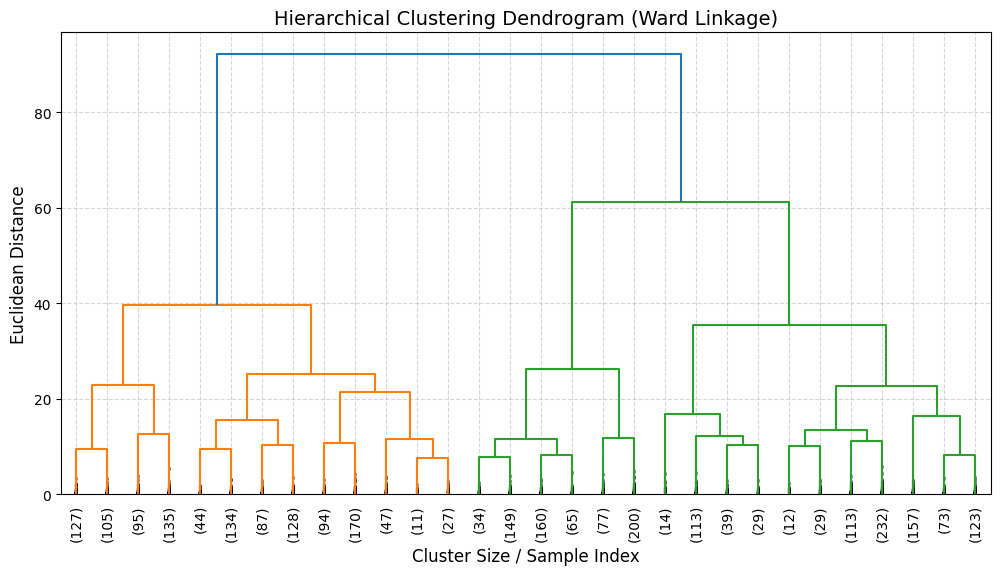


Hierarchical Cluster Counts:
Hierarchical_Cluster
1    1204
2     685
3     934
Name: count, dtype: int64

             K-MEANS CLUSTER MEANS SUMMARY             
                QUANTITYORDERED  PRICEEACH        SALES        MSRP
KMeans_Cluster                                                     
0                     35.208205  59.551169  2101.076482   64.145641
1                     43.723005  97.479261  5720.080669  127.893192
2                     27.597390  95.435090  3123.062801  113.266064


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler

print("Downloading Sample Sales dataset from Kaggle...")
path = kagglehub.dataset_download("kyanyoga/sample-sales-data")

csv_file = [os.path.join(path, f) for f in os.listdir(path) if f.endswith('.csv')][0]
try:
    df = pd.read_csv(csv_file, encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv(csv_file, encoding='latin1')

print(f"Dataset loaded successfully! Initial shape: {df.shape}")

features = ['QUANTITYORDERED', 'PRICEEACH', 'SALES', 'MSRP']
X = df[features].copy()

X.fillna(X.median(), inplace=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Method for Optimal K (K-Means)', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"\nOptimal Clusters determined by Elbow Method: {optimal_k}")
print("\nK-Means Cluster Counts:")
print(df['KMeans_Cluster'].value_counts().sort_index())

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14)
plt.xlabel('Cluster Size / Sample Index', fontsize=12)
plt.ylabel('Euclidean Distance', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

df['Hierarchical_Cluster'] = fcluster(linked, t=optimal_k, criterion='maxclust')

print("\nHierarchical Cluster Counts:")
print(df['Hierarchical_Cluster'].value_counts().sort_index())

print("\n" + "="*60)
print("             K-MEANS CLUSTER MEANS SUMMARY             ")
print("="*60)
cluster_summary = df.groupby('KMeans_Cluster')[features].mean()
print(cluster_summary)
print("="*60)